In [1]:
# Imports for this notebook
import gc
import os
import warnings
import traceback
from typing import List, Tuple, Callable

# Debugger
from IPython.core.debugger import set_trace

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import xgboost as xgb
import joblib

%matplotlib inline
def garbage_collect(names):
    for n in names:
        if n in globals():
            del globals()[n]
    gc.collect()

In [2]:
# 1) Load dataset and quick overview
df = pd.read_excel("Diagnosis3.xlsx")
print("Rows, cols:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))
print("\nMissing values per column:")
display(df.isna().sum())

Rows, cols: (12093, 12)


,Mem.#,City,State,DOB,DOS From,Units,Proc. Code,D1,D2,D3,D4,M1
0,TM89503J,FLUSHING,NY,04/16/1964,08/02/2023,1,99496,I50.22,I25.10,E78.5,NaN,25
1,K6094471101,flushing,NY,10/28/1995,09/06/2023,1,99214,L03.211,R51.9,E16.2,E55.9,NaN
2,746439162,BRONX,NY,08/03/1961,04/27/2024,30,95165,J30.1,J30.5,J30.81,J30.89,NaN
3,954587440,Fresh Meadows,NY,02/18/1983,02/22/2024,1,99213,E78.2,E55.9,B19.10,D72.819,NaN
4,JLJ730753437,Flushing,NY,08/01/1950,03/19/2024,1,99442,E78.2,E11.65,J45.20,NaN,25



Columns: ['Mem.#', 'City', 'State', 'DOB', 'DOS From', 'Units', 'Proc. Code', 'D1', 'D2', 'D3', 'D4', 'M1']

Missing values per column:


Mem.#            1
City             0
State            0
DOB              0
DOS From         0
Units            0
Proc. Code       0
D1             848
D2            3699
D3            6213
D4            8930
M1            8254
dtype: int64

In [3]:
# 2) Preprocessing - create Age, DOS_Weekday, DOS_Month; drop Mem.#
df = df.copy()

# Convert datetimes
df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
df['DOS From'] = pd.to_datetime(df['DOS From'], errors='coerce')

# Age in years (floor) — fill missing with -1 sentinel
df['Age'] = ((df['DOS From'] - df['DOB']).dt.days // 365).fillna(-1).astype(int)

# DOS features
df['DOS_Weekday'] = df['DOS From'].dt.weekday.fillna(-1).astype(int)
df['DOS_Month'] = df['DOS From'].dt.month.fillna(-1).astype(int)

# Drop identifier column Mem.# (IDs shouldn't be features)
if 'Mem.#' in df.columns:
    df.drop(columns=['Mem.#'], inplace=True)

# drop original date columns to avoid leaking raw dates
for c in ['DOB','DOS From']:
    if c in df.columns:
        df.drop(columns=[c], inplace=True)

print("After preprocessing columns:", df.columns.tolist())
display(df.head())

After preprocessing columns: ['City', 'State', 'Units', 'Proc. Code', 'D1', 'D2', 'D3', 'D4', 'M1', 'Age', 'DOS_Weekday', 'DOS_Month']


,City,State,Units,Proc. Code,D1,D2,D3,D4,M1,Age,DOS_Weekday,DOS_Month
0,FLUSHING,NY,1,99496,I50.22,I25.10,E78.5,NaN,25,59,2,8
1,flushing,NY,1,99214,L03.211,R51.9,E16.2,E55.9,NaN,27,2,9
2,BRONX,NY,30,95165,J30.1,J30.5,J30.81,J30.89,NaN,62,5,4
3,Fresh Meadows,NY,1,99213,E78.2,E55.9,B19.10,D72.819,NaN,41,3,2
4,Flushing,NY,1,99442,E78.2,E11.65,J45.20,NaN,25,73,1,3


In [4]:
# 3) Define D1 as the single target and set features
target_col = 'D1'
assert target_col in df.columns, "D1 not found in dataframe"

# Fill missing diagnoses with "None" token
df[target_col] = df[target_col].fillna("None")

# Feature columns are everything except D1
feature_cols = [c for c in df.columns if c != target_col]
print("Number of features:", len(feature_cols))
print(feature_cols)


Number of features: 11
['City', 'State', 'Units', 'Proc. Code', 'D2', 'D3', 'D4', 'M1', 'Age', 'DOS_Weekday', 'DOS_Month']


In [5]:
# 4) Group rare labels (adjust rare_threshold as needed)
rare_threshold = 20   # labels with fewer than this many samples -> 'Other'
counts = df[target_col].value_counts()
rare_labels = counts[counts < rare_threshold].index.tolist()
print("Unique D1 before grouping:", counts.size)
print(f"Grouping {len(rare_labels)} rare labels (count < {rare_threshold}) into 'Other'")

df['D1_grouped'] = df[target_col].apply(lambda x: 'Other' if x in rare_labels else x)
# Use grouped target
target = 'D1_grouped'
print("Unique grouped labels:", df[target].nunique())
display(df[target].value_counts().head(30))

Unique D1 before grouping: 472
Grouping 415 rare labels (count < 20) into 'Other'
Unique grouped labels: 58


D1_grouped
I10        2179
Other      1513
Z00.00     1330
E78.2       892
Z00.01      850
None        848
E78.5       723
E11.65      563
J20.9       367
R53.82      204
J06.9       192
R53.83      172
E11.9       171
M54.50      153
Z23         153
G47.00      109
J30.9        99
R50.9        92
Z01.818      85
R73.03       74
L20.9        61
E66.9        60
J09.X2       60
E55.9        57
J02.9        52
J30.1        52
R19.7        45
R42          45
K21.9        44
L30.9        44
Name: count, dtype: int64

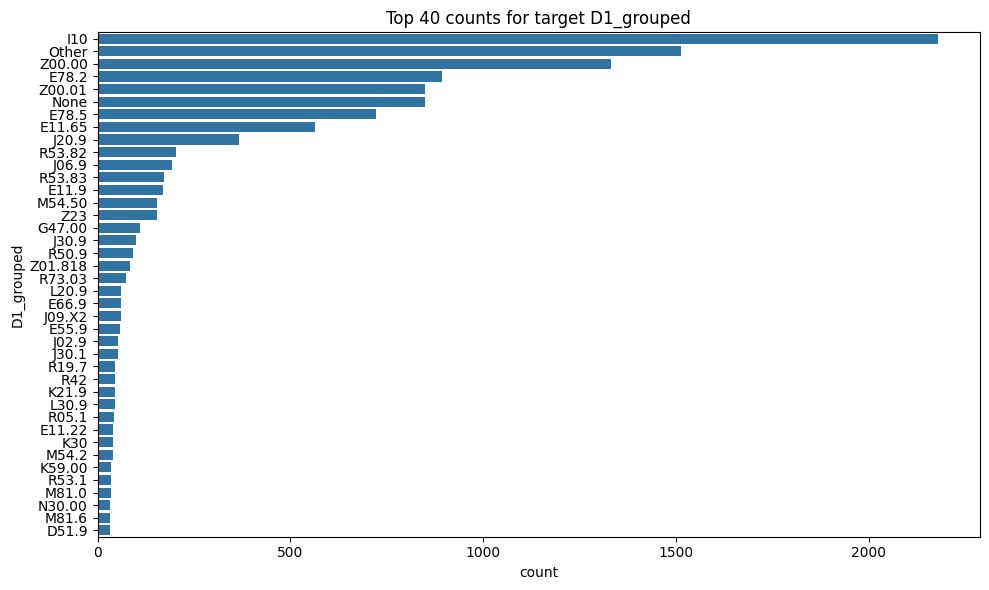

In [6]:
# 5A) Target distribution top counts
plt.figure(figsize=(10,6))
order = df[target].value_counts().index
sns.countplot(y=target, data=df, order=order[:40])
plt.title(f"Top 40 counts for target {target}")
plt.tight_layout()
plt.show()

Numeric columns: ['Units', 'Age', 'DOS_Weekday', 'DOS_Month']


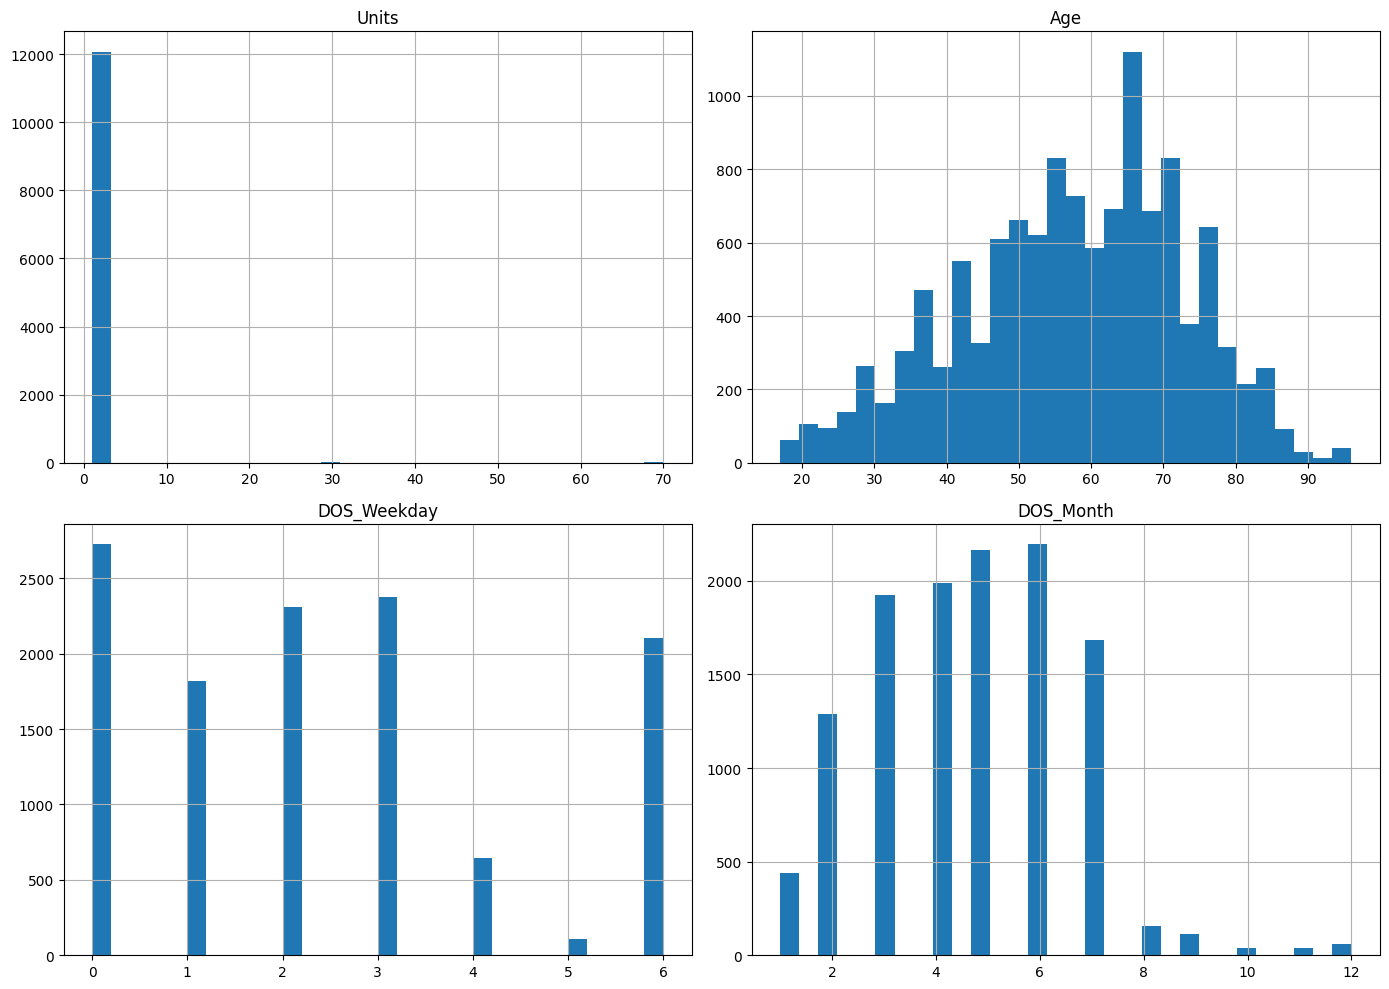

In [7]:
# 5B) Numeric columns histograms
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)
if len(num_cols) > 0:
    df[num_cols].hist(figsize=(14,10), bins=30)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found.")

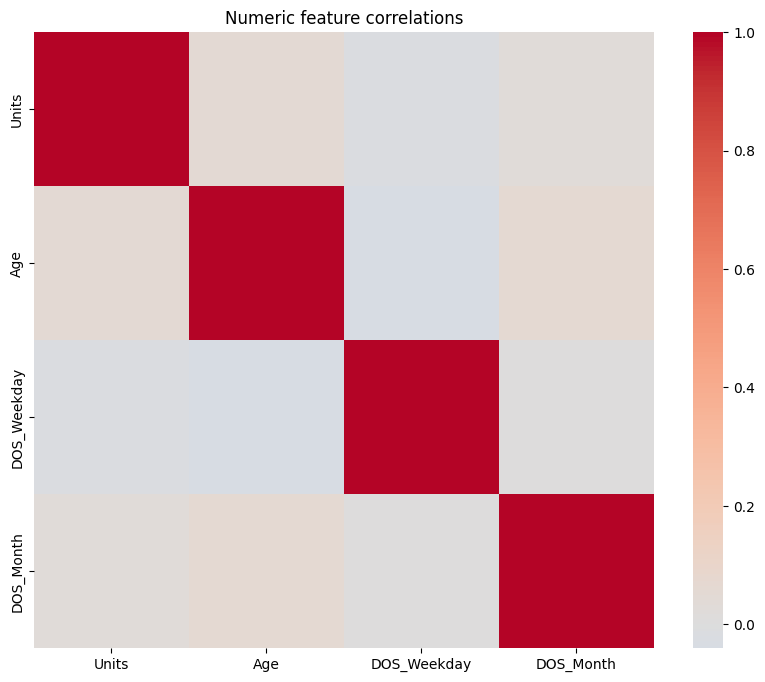

In [8]:
# 5C) Correlation heatmap (numeric only)
if len(num_cols) > 1:
    plt.figure(figsize=(10,8))
    sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0)
    plt.title("Numeric feature correlations")
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")

In [9]:
# 6) Label-encode categorical features for XGBoost
X = df[feature_cols].copy()

# detect categorical/object columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns to encode:", cat_cols)

feature_label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X.loc[:, col] = le.fit_transform(X[col].astype(str).fillna("None"))
    feature_label_encoders[col] = le

# Ensure numeric dtype; for safety fill na with -1
X = X.apply(pd.to_numeric, errors='coerce').fillna(-1).astype(np.int32)

display(X.head())


Categorical columns to encode: ['City', 'State', 'Proc. Code', 'D2', 'D3', 'D4', 'M1']


,City,State,Units,Proc. Code,D2,D3,D4,M1,Age,DOS_Weekday,DOS_Month
0,35,4,1,77,143,63,354,0,59,2,8
1,156,4,1,62,419,49,41,7,27,2,9
2,8,4,30,48,178,152,108,7,62,5,4
3,50,4,1,61,60,6,26,7,41,3,2
4,44,4,1,71,52,160,354,0,73,1,3


In [10]:
# 7) Stratified train/val/test split on the chosen target
y = df[[target]].copy()

def train_valid_test_split_strat(X, y, seed=42, test_size=0.2, val_frac_of_train=0.2, strat_col=None):
    stratify_col = y[strat_col] if strat_col is not None else None
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=stratify_col)
    stratify_col2 = y_trn[strat_col] if strat_col is not None else None
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_trn, y_trn, test_size=val_frac_of_train, random_state=seed, stratify=stratify_col2)
    for d in [X_trn, X_vld, X_tst, y_trn, y_vld, y_tst]:
        d.reset_index(drop=True, inplace=True)
    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = train_valid_test_split_strat(X, y, strat_col=target)
print("Shapes:", X_trn.shape, X_vld.shape, X_tst.shape)
print("Train target distribution (top 20):")
display(y_trn[target].value_counts().head(20))

Shapes: (7739, 11) (1935, 11) (2419, 11)
Train target distribution (top 20):


D1_grouped
I10        1394
Other       968
Z00.00      851
E78.2       570
Z00.01      544
None        542
E78.5       462
E11.65      360
J20.9       235
R53.82      130
J06.9       123
E11.9       110
R53.83      110
M54.50       98
Z23          98
G47.00       70
J30.9        63
R50.9        59
Z01.818      54
R73.03       47
Name: count, dtype: int64

In [11]:
# 8) Fit LabelEncoder on training labels only (safe)
target_le = LabelEncoder()
target_le.fit(y_trn[target].astype(str))
y_trn_enc = target_le.transform(y_trn[target].astype(str))

# safe transform for val and test: unseen -> -1
def safe_transform_target(series, le):
    out = []
    for v in series.astype(str):
        out.append(le.transform([v])[0] if v in le.classes_ else -1)
    return np.array(out, dtype=np.int32)

y_vld_enc = safe_transform_target(y_vld[target], target_le)
y_tst_enc = safe_transform_target(y_tst[target], target_le)

print("Number of classes learned from training:", len(target_le.classes_))
print("Example training classes (first 20):", target_le.classes_[:20])


Number of classes learned from training: 58
Example training classes (first 20): ['B18.1' 'D51.9' 'D72.819' 'E11.22' 'E11.65' 'E11.8' 'E11.9' 'E55.9'
 'E66.9' 'E78.2' 'E78.5' 'G47.00' 'I10' 'J02.9' 'J06.9' 'J09.X2' 'J20.9'
 'J30.1' 'J30.9' 'K08.89']


In [12]:
import xgboost as xgb
import numpy as np

# Initialize model
clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_trn_enc)),
    tree_method='hist',
    max_depth=6,
    learning_rate=0.05,
    n_estimators=500,
    early_stopping_rounds=30
)

# class balancing via sample weights
classes, counts = np.unique(y_trn_enc, return_counts=True)
class_weights = {c: max(counts)/count for c,count in zip(classes, counts)}
sample_weights = np.array([class_weights[c] for c in y_trn_enc], dtype=np.float32)

# Fit model 
clf.fit(
    X_trn,
    y_trn_enc,
    sample_weight=sample_weights,
    eval_set=[(X_vld, y_vld_enc)],
    verbose=True,
)

[0]	validation_0-mlogloss:3.58480
[1]	validation_0-mlogloss:3.36448
[2]	validation_0-mlogloss:3.21228
[3]	validation_0-mlogloss:3.09385
[4]	validation_0-mlogloss:2.99341
[5]	validation_0-mlogloss:2.90754
[6]	validation_0-mlogloss:2.83250
[7]	validation_0-mlogloss:2.76607
[8]	validation_0-mlogloss:2.70599
[9]	validation_0-mlogloss:2.64972
[10]	validation_0-mlogloss:2.59474
[11]	validation_0-mlogloss:2.54824
[12]	validation_0-mlogloss:2.50211
[13]	validation_0-mlogloss:2.46102
[14]	validation_0-mlogloss:2.42038
[15]	validation_0-mlogloss:2.38280
[16]	validation_0-mlogloss:2.34617
[17]	validation_0-mlogloss:2.31086
[18]	validation_0-mlogloss:2.27770
[19]	validation_0-mlogloss:2.24679
[20]	validation_0-mlogloss:2.21743
[21]	validation_0-mlogloss:2.18894
[22]	validation_0-mlogloss:2.16247
[23]	validation_0-mlogloss:2.13817
[24]	validation_0-mlogloss:2.11580
[25]	validation_0-mlogloss:2.09295
[26]	validation_0-mlogloss:2.07161
[27]	validation_0-mlogloss:2.05062
[28]	validation_0-mlogloss:2.0

,objective,'multi:softprob'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,30
,enable_categorical,False
,eval_metric,None


Valid test samples: 2419

Classification report (test):
              precision    recall  f1-score   support

       B18.1       0.08      0.17      0.11         6
       D51.9       0.56      0.83      0.67         6
     D72.819       0.50      0.25      0.33         4
      E11.22       1.00      1.00      1.00         8
      E11.65       0.89      0.90      0.89       113
       E11.8       1.00      0.75      0.86         4
       E11.9       0.64      0.53      0.58        34
       E55.9       0.14      0.09      0.11        11
       E66.9       1.00      1.00      1.00        12
       E78.2       0.73      0.71      0.72       179
       E78.5       0.48      0.59      0.53       145
      G47.00       0.14      0.18      0.16        22
         I10       0.90      0.83      0.86       436
       J02.9       0.45      0.50      0.48        10
       J06.9       0.40      0.50      0.45        38
      J09.X2       0.75      0.75      0.75        12
       J20.9       0.41  

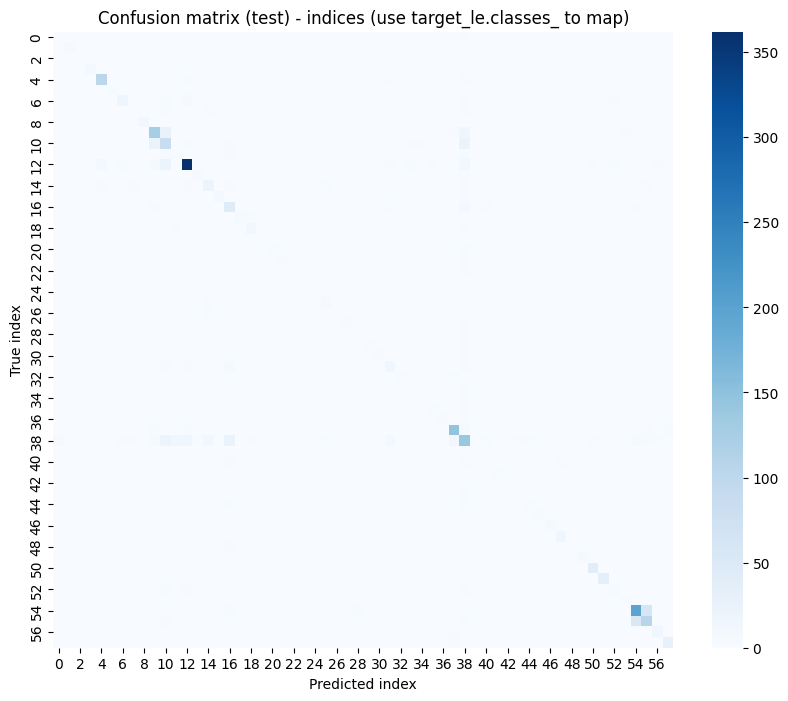

In [13]:
# 10) Evaluate on test set
proba = clf.predict_proba(X_tst)
y_pred_idx = np.argmax(proba, axis=1).astype(int)

# Filter valid positions where true label is not -1
mask = (y_tst_enc != -1)
if mask.sum() == 0:
    print("No valid test samples (all test labels were unseen). Consider grouping more labels or using a different split.")
else:
    y_true_valid = y_tst_enc[mask]
    y_pred_valid = y_pred_idx[mask]
    print("Valid test samples:", mask.sum())
    print("\nClassification report (test):")
    print(classification_report(y_true_valid, y_pred_valid, target_names=target_le.classes_, zero_division=0))
    acc = accuracy_score(y_true_valid, y_pred_valid)
    f1 = f1_score(y_true_valid, y_pred_valid, average='weighted', zero_division=0)
    print(f"Accuracy: {acc:.4f}  |  Weighted F1: {f1:.4f}")

    # Confusion matrix (visual)
    cm = confusion_matrix(y_true_valid, y_pred_valid)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title("Confusion matrix (test) - indices (use target_le.classes_ to map)")
    plt.xlabel("Predicted index")
    plt.ylabel("True index")
    plt.show()


In [14]:
# 11) Confusion matrix with labels (only if classes <= ~30 otherwise unreadable)
num_classes = len(target_le.classes_)
if num_classes <= 30 and mask.sum() > 0:
    cm = confusion_matrix(y_true_valid, y_pred_valid)
    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_le.classes_, yticklabels=target_le.classes_)
    plt.title("Confusion matrix (labels)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()
else:
    print(f"Skipping labeled confusion matrix: classes={num_classes}, valid_samples={mask.sum()}")


Skipping labeled confusion matrix: classes=58, valid_samples=2419


<Figure size 800x1000 with 0 Axes>

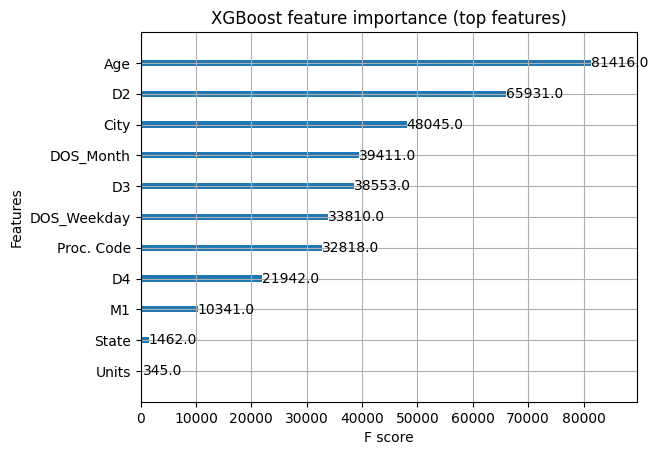

In [15]:
# 12) Feature importance
plt.figure(figsize=(8,10))
try:
    xgb.plot_importance(clf, max_num_features=30)
    plt.title("XGBoost feature importance (top features)")
    plt.show()
except Exception:
    fi = pd.Series(clf.feature_importances_, index=X_trn.columns).sort_values(ascending=False).head(30)
    fi.plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title("Feature importance (approx.)")
    plt.show()


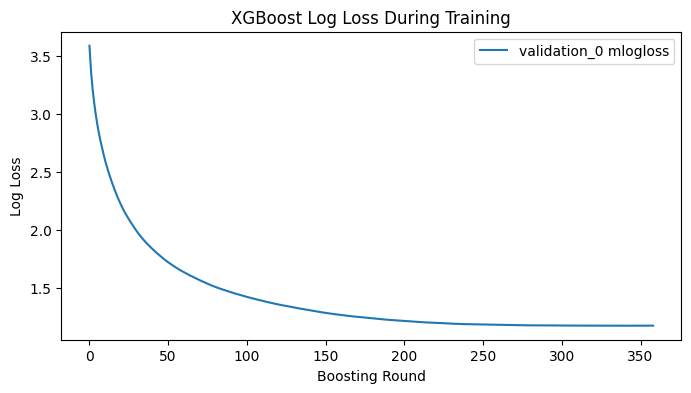

In [16]:
# 13) Learning curve (logloss) using eval_set
# Check if evals_result exists after training
if hasattr(clf, "evals_result_"):  # note the trailing underscore for newer versions
    er = clf.evals_result_  # store results
    plt.figure(figsize=(8,4))
    
    for key in er.keys():  # e.g., 'validation_0'
        if 'mlogloss' in er[key]:  # make sure 'mlogloss' is available
            plt.plot(er[key]['mlogloss'], label=f"{key} mlogloss")
    
    plt.xlabel("Boosting Round")
    plt.ylabel("Log Loss")
    plt.title("XGBoost Log Loss During Training")
    plt.legend()
    plt.show()
else:
    print("No evals_result available. Make sure you trained with eval_set and early_stopping_rounds.")


C:\Users\elife\anaconda3\envs\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\elife\anaconda3\envs\myenv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Polynomial Logistic Regression (degree=2) - Validation Accuracy: 0.1168, Weighted F1: 0.1197


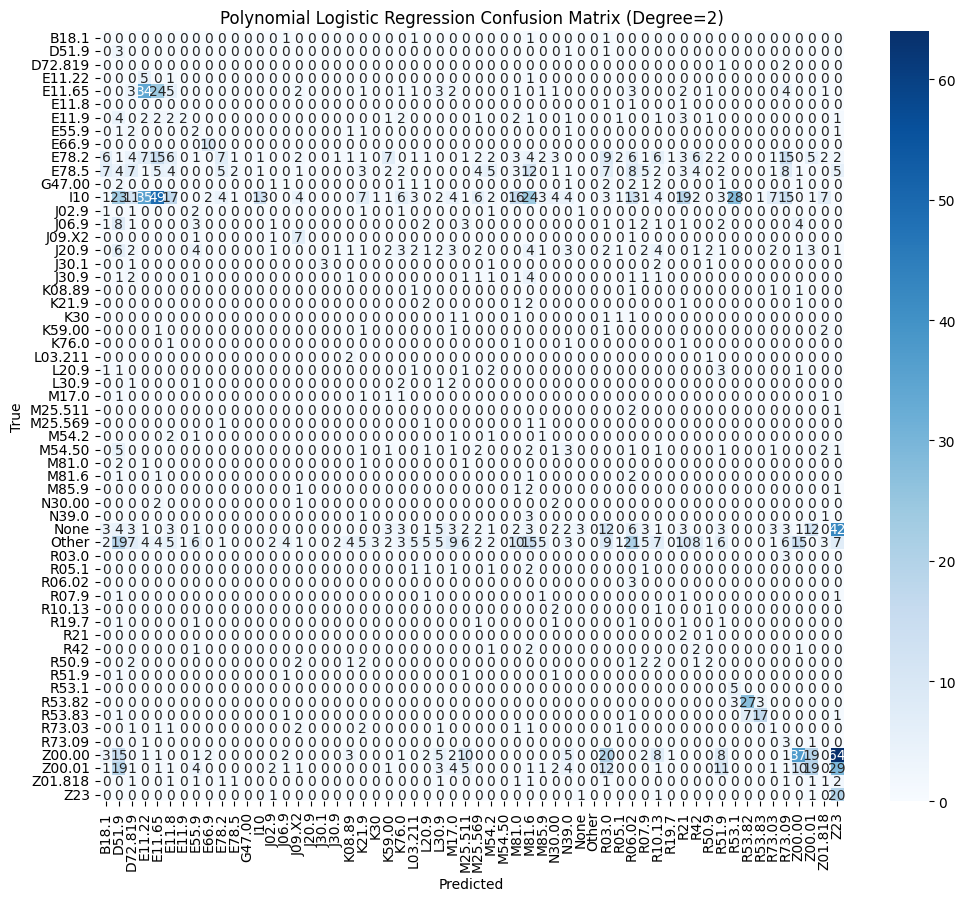

In [17]:
# 14) Polynomial features + Regularized Logistic Regression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# For demonstration, let's try degree 2 polynomial features
poly_degree = 2

# Pipeline: scaling -> polynomial -> logistic regression
poly_lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # scale numeric features
    ('poly', PolynomialFeatures(degree=poly_degree, include_bias=False)),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        max_iter=1000,
        solver='saga',  # handles L1/L2 regularization efficiently
        penalty='l2',   # L2 regularization (Ridge)
        C=1.0,          # inverse of regularization strength
        class_weight='balanced'
    ))
])

# Fit pipeline on training data
poly_lr_pipeline.fit(X_trn, y_trn[target])

# Evaluate on validation set
y_vld_pred = poly_lr_pipeline.predict(X_vld)
acc_vld = accuracy_score(y_vld[target], y_vld_pred)
f1_vld = f1_score(y_vld[target], y_vld_pred, average='weighted', zero_division=0)
print(f"Polynomial Logistic Regression (degree={poly_degree}) - Validation Accuracy: {acc_vld:.4f}, Weighted F1: {f1_vld:.4f}")

# Confusion matrix for validation
cm_vld = confusion_matrix(y_vld[target], y_vld_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm_vld, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.title(f"Polynomial Logistic Regression Confusion Matrix (Degree={poly_degree})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [18]:
# 15) Test set evaluation
y_tst_pred = poly_lr_pipeline.predict(X_tst)
mask_test = y_tst_enc != -1
y_true_test = y_tst_enc[mask_test]
y_pred_test = target_le.transform(y_tst_pred[mask_test])

acc_test = accuracy_score(y_true_test, y_pred_test)
f1_test = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
print(f"Polynomial Logistic Regression (degree={poly_degree}) - Test Accuracy: {acc_test:.4f}, Weighted F1: {f1_test:.4f}")

# 16) Save models and encoders
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

# Save XGBoost model
xgb_model_path = os.path.join(model_dir, "xgb_model.joblib")
joblib.dump(clf, xgb_model_path)

# Save Polynomial Logistic Regression pipeline
poly_lr_path = os.path.join(model_dir, f"poly_lr_deg{poly_degree}.joblib")
joblib.dump(poly_lr_pipeline, poly_lr_path)

# Save label encoders
encoders_path = os.path.join(model_dir, "feature_label_encoders.joblib")
joblib.dump(feature_label_encoders, encoders_path)

target_le_path = os.path.join(model_dir, "target_le.joblib")
joblib.dump(target_le, target_le_path)

print(f"Models and encoders saved in '{model_dir}'")


Polynomial Logistic Regression (degree=2) - Test Accuracy: 0.1116, Weighted F1: 0.1087
Models and encoders saved in 'models'


In [19]:
# 17) Optional: Compare XGBoost vs Polynomial LR performance
print(f"\nComparison of models on test set (weighted F1):")
print(f"XGBoost F1: {f1:.4f}")
print(f"Poly Logistic Regression F1: {f1_test:.4f}")


Comparison of models on test set (weighted F1):
XGBoost F1: 0.6656
Poly Logistic Regression F1: 0.1087
